Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

1. Rozważ zbiór danych [Air Quality](https://archive.ics.uci.edu/dataset/360/air+quality)
1. [0-3 pkt] Dokonaj wstępnego przetwarzania danych. Skomentuj poszczególne kroki i podjęte decyzje. **Uwagi**:
   1. kluczowe jest zapoznanie się z opisem zbioru danych
   1. nie interesuje nas tu zależność czasowa - nie traktujemy tego zbioru jako serii czasowej. Jednak rozważ użycie miesiąca jako zmiennej kategorycznej
   1. jaką inną zmienną powinniśmy wyłączyć z analizy? Dlaczego?
   1. jako zmienną zależną (*target*) rozważ sumę koncentracji poszczególnych związków (ozn. `GT`). Czy sumę liczymy przed czy po skalowaniu cech?
1. [0-2 pkt] Użyj:
   1. modelu liniowego
   1. modelu liniowego z regularyzcją L1
   1. modelu liniowego z regularyzcją L2
   1. regresji Hubera
1. [0-2 pkt] Porównaj poszczególne modele dla domyślnych parametrów oraz różnych wartości regularyzacji (użyj [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html))
1. [0-1 pkt] Skomentuj uzyskane wyniki m.in. odnośnie wartości RMSE i MAE oraz czasu treningu
1. [0-1 pkt] Zbadaj wpływ wstępnego przetwarzania danych (np. wpływu skorelowanych cech, usuwania zmiennych katagorycznych, normalizacji) na wyniki. W tym celu możesz użyć klasy [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
1. [0-1 pkt] Zwizualizuj wartości parametrów, porównując wszystkie modele razem. Jak wybór parametrów wpływa na osiągi modelu?
  
<span style="color:red">**Uwaga:**</span> zadania bez komentarzy i wniosków zostaną ocenione na **0 punktów**

# Zadanie dodatkowe [0-3] pkt

Użyj modelu liniowych efektów mieszanych w zadaniu wyżej:
1. Wykorzystaj API ze [statsmodels](https://www.statsmodels.org/stable/mixed_linear.html)
1. Użyj miesiąca jako zmiennej modelującej efekt losowy (potencjalny *bias*)
1. Skomentuj wyniki w porównaniu do zadania wyżej (miesiąc jako zmienna kategoryczna)

## Pobranie i preprocessing danych Air Quality

In [1]:
!pip install ucimlrepo

In [2]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

air_quality = fetch_ucirepo(id=360)

X = air_quality.data.features
y = air_quality.data.targets

In [3]:
X.head(5)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [4]:
type(X),type(y)

(pandas.core.frame.DataFrame, NoneType)

W opisie zbioru jest napisane, że brakujące wartości są zakodowane jako -200

In [5]:
import numpy as np
X = X.replace(-200, np.nan)

In [6]:
missing_values = X.isna().sum()
print(missing_values)

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


Zgodnie z poleceniem, należy wykluczyć kolumnę Time oraz, w związku z bardzo dużą liczbą brakujących wartości (prawie 8500 na niecałe 10000 rekordów), kolumnę NMHC (GT). Jako target wykorzystam sumę koncentracji kolumn CO, C6H6, NOx oraz NO2.

In [7]:
X = X.drop(columns=['Time','NMHC(GT)'])

In [8]:
missing_in_rows = X.isna().sum(axis=1)
missing_row_distributions = missing_in_rows.value_counts().sort_index()
print(missing_row_distributions)

0     6941
1      455
2      400
3     1195
9      317
10       5
11      13
12      31
Name: count, dtype: int64


In [9]:
X = X[X.isna().sum(axis=1) < 9].copy()

Przy sprawdzaniu brakujących wartości w zależności od kolumny, zauważyłem, że dla większości kolumn powtarza się liczba wierszy z brakującymi wartościami. Po sprawdzeniu liczby brakujących wartości w poszczególnych wartości, doszedłem do wniosku, że usunięcie wierszy z 9 lub więcej brakującymi wartościami powinno poprawić jakość zbioru danych.

Sprawdzenie, czy wszystko zostało wykonane zgodnie z zamierzeniami:

In [10]:
missing_in_rows = X.isna().sum(axis=1)
missing_row_distributions = missing_in_rows.value_counts().sort_index()
print(missing_row_distributions)

0    6941
1     455
2     400
3    1195
Name: count, dtype: int64


Wprowadzenie miesiąca jako zmiennej kategorycznej

In [11]:
X['Date'] = pd.to_datetime(X['Date'],format='%m/%d/%Y')
X['Month'] = X['Date'].dt.month.astype('category')

Przygotowanie targetu:

In [12]:
from sklearn.impute import SimpleImputer

gt_columns = ['CO(GT)','C6H6(GT)','NOx(GT)','NO2(GT)']
imputer = SimpleImputer(strategy='median')
X[gt_columns] = imputer.fit_transform(X[gt_columns])

y = X[gt_columns].sum(axis=1)
X = X.drop(columns=gt_columns+ ['Date'])


In [13]:
X.head(5)

,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Month
0,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578,3
1,1292.0,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255,3
2,1402.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502,3
3,1376.0,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867,3
4,1272.0,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888,3


In [14]:
y.head(5)

,0
0,293.5
1,206.4
2,256.2
3,305.4
4,255.1


Sumę po wartościach GT liczymy przed ich skalowaniem, ponieważ chcemy przewidywać sumę stężeń. Gdybyśmy dokonali skalowania przed ich zsumowaniem, fizyczny sens tej danej zostałby zmieniony.

Pozostały preprocessing danych - one hot encoding na zmiennej Month oraz imputacja dla danych z X

In [15]:
from sklearn.preprocessing import OneHotEncoder

cols_to_impute = X.columns.drop('Month')
imputer_x = SimpleImputer(strategy='median')
X[cols_to_impute] = imputer_x.fit_transform(X[cols_to_impute])

month_encoder = OneHotEncoder(drop='first',sparse_output=False)
month_encoded = month_encoder.fit_transform(X[['Month']])

# needed to match the indices in joining X (because of removal rows in earlier in this dataset)
month_encoded_df = pd.DataFrame(
    month_encoded,
    columns=month_encoder.get_feature_names_out(['Month']),
    index=X.index
)

X = X.drop(columns=['Month']).join(month_encoded_df)

Sprawdzenie

In [16]:
X.shape

(8991, 19)

In [17]:
X.isna().sum().sum()

np.int64(0)

In [18]:
X.head(5)

,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1292.0,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1402.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1376.0,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1272.0,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Wizualizacja korelacji danych

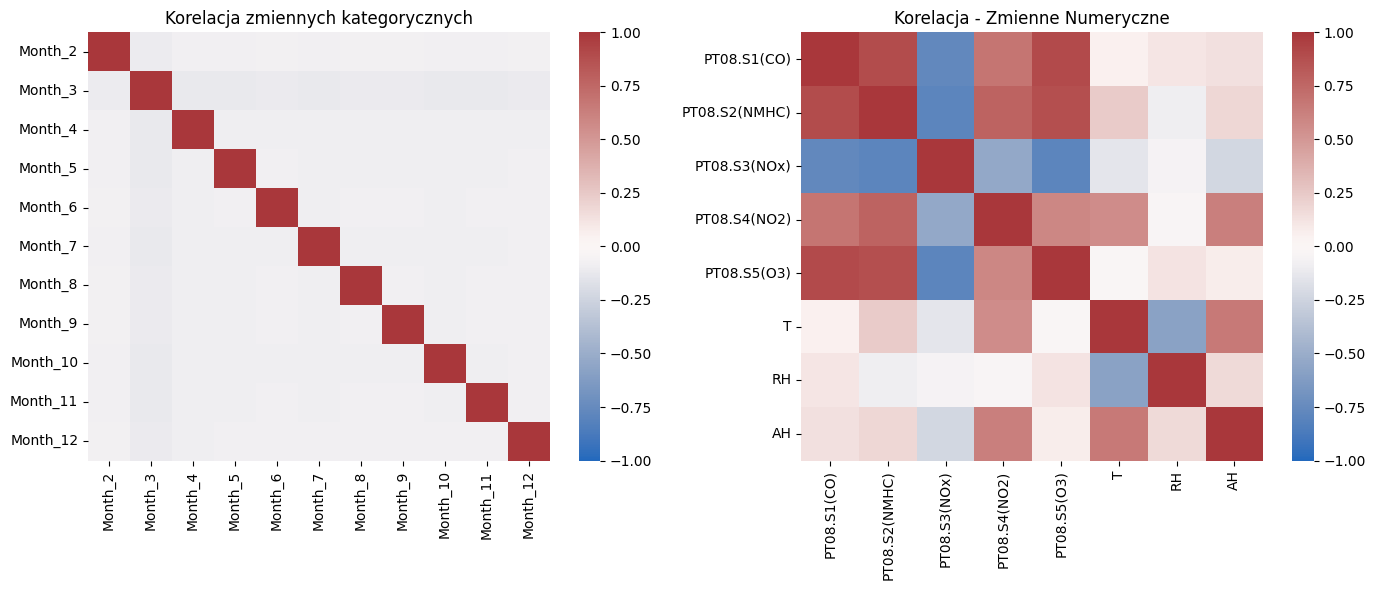

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

corrs_month = month_encoded_df.corr()

corrs_num = X.drop(columns=month_encoded_df.columns).corr()

kwargs = {'cmap':'vlag','vmin':-1,'vmax':1}
fig, ax = plt.subplots(1,2,figsize=(14,6))

sns.heatmap(corrs_month,ax=ax[0],**kwargs)
ax[0].set_title('Korelacja zmiennych kategorycznych')

sns.heatmap(corrs_num, ax=ax[1], **kwargs)
ax[1].set_title("Korelacja - Zmienne Numeryczne")

plt.tight_layout()
plt.show()


Tak jak należało się spodziewać, zmienne kategoryczne - miesiące nie wykazują silnych korelacji, ponieważ się wykluczają.
Jeśli chodzi o zmienne numeryczne, to widać silną korelację dodatnią między PT08.S1(CO) a PT08.S2(NHMC), oraz silną korelację ujemną między PT08.S3(NOx) z innymi PT08. Widać też korelację dodatnią między PT08.S5 a S1 i S2.

Usuwamy jedną z pary silnie skorelowanych zmiennych

In [20]:
def remove_highly_correlated_features(df, threshold=0.8):
  corr_matrix = df.corr()
  upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
  to_drop = {
      column if df[column].var() < df[feature].var() else feature
      for column in upper_tri.columns
      for feature in upper_tri.index[upper_tri[column] >= threshold]
  }
  return df.drop(columns=to_drop)

In [21]:
X_uncorr = remove_highly_correlated_features(X,0.8)

In [22]:
X_uncorr.head(5)

,PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,1056.0,1692.0,1268.0,13.6,48.9,0.7578,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1174.0,1559.0,972.0,13.3,47.7,0.7255,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1140.0,1555.0,1074.0,11.9,54.0,0.7502,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1092.0,1584.0,1203.0,11.0,60.0,0.7867,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1205.0,1490.0,1110.0,11.2,59.6,0.7888,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Standaryzacja danych

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_uncorr),
    columns=X_uncorr.columns,
    index=X_uncorr.index
)

Split datasetu

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2,random_state=0)

## Metody liniowe

funkcja do ewaluacji modeli

In [39]:
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_model(model, X_train, y_train, X_test, y_test):
  start_time = time.time()
  model.fit(X_train, y_train)
  end_time = time.time()
  train_time = end_time - start_time

  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)

  rmse_train = mean_squared_error(y_train, y_pred_train)
  rmse_test = mean_squared_error(y_test, y_pred_test)
  mae_train = mean_absolute_error(y_train, y_pred_train)
  mae_test = mean_absolute_error(y_test, y_pred_test)

  print(f"Training Time: {train_time:.4f}")
  print(f"Train RMSE: {rmse_train:.2f}")
  print(f"Test RMSE: {rmse_test:.2f}")
  print(f"Train MAE: {mae_train:.2f}")
  print(f"Test MAE: {mae_test:.2f}")


In [41]:
def grid_search_model(model, param_grid, X_train, y_train, X_test, y_test):
  grid_search = GridSearchCV(model, param_grid, scoring='neg_mean_squared_error',cv=5,n_jobs=-1)
  start_time = time.time()
  grid_search.fit(X_train, y_train)
  end_time = time.time()
  train_time = end_time - start_time

  best_model = grid_search.best_estimator_
  best_params = grid_search.best_params_
  print(f"Training Time: {train_time:.4f}")
  print(f"Best Parameters: {best_params}")

  return best_model

Regresja liniowa

In [28]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
evaluate_model(lr_model, X_train, y_train, X_test, y_test)

test started
Training Time: 0.04
Train RMSE: 15067.71
Test RMSE: 14758.57
Train MAE: 90.41
Test MAE: 90.97


model z regularyzacją L1

In [32]:
from sklearn.linear_model import Lasso

lasso_model = Lasso()
print(f"alpha: {lasso_model.alpha}")
evaluate_model(lasso_model, X_train, y_train, X_test, y_test)

alpha: 1.0
test started
Training Time: 0.01
Train RMSE: 15169.92
Test RMSE: 14761.33
Train MAE: 90.64
Test MAE: 90.52


In [43]:
from sklearn.model_selection import GridSearchCV

lasso_grid = {'alpha':[0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

lasso_best_model = grid_search_model(Lasso(), lasso_grid, X_train, y_train, X_test, y_test)
evaluate_model(lasso_best_model, X_train, y_train, X_test, y_test)


Training Time: 0.6477
Best Parameters: {'alpha': 0.001}
Training Time: 0.0357
Train RMSE: 15067.72
Test RMSE: 14758.44
Train MAE: 90.41
Test MAE: 90.96


model z regularyzacją l2

In [33]:
from sklearn.linear_model import Ridge

ridge_model = Ridge()
print(f"alpha: {ridge_model.alpha}")
evaluate_model(ridge_model,X_train, y_train, X_test, y_test)

alpha: 1.0
test started
Training Time: 0.01
Train RMSE: 15067.72
Test RMSE: 14757.78
Train MAE: 90.41
Test MAE: 90.96


In [44]:
ridge_grid = {'alpha':[0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_best_model = grid_search_model(Ridge(), ridge_grid, X_train, y_train, X_test, y_test)
evaluate_model(ridge_best_model, X_train, y_train, X_test, y_test)

Training Time: 0.2715
Best Parameters: {'alpha': 1.0}
Training Time: 0.0045
Train RMSE: 15067.72
Test RMSE: 14757.78
Train MAE: 90.41
Test MAE: 90.96


regresja Hubera

In [36]:
from sklearn.linear_model import HuberRegressor

huber_model = HuberRegressor()
print(f"epsilon: {huber_model.epsilon}, alpha: {huber_model.alpha}")
evaluate_model(huber_model, X_train, y_train, X_test, y_test)

epsilon: 1.35, alpha: 0.0001
test started
Training Time: 0.09
Train RMSE: 15676.99
Test RMSE: 14963.50
Train MAE: 88.68
Test MAE: 88.22


In [45]:
huber_grid = {
    'epsilon': [1.20, 1.35, 1.5, 1.65],
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]
}

huber_best_model = grid_search_model(HuberRegressor(), huber_grid, X_train, y_train, X_test, y_test)
evaluate_model(huber_best_model, X_train, y_train, X_test, y_test)

Training Time: 7.6742
Best Parameters: {'alpha': 0.0001, 'epsilon': 1.65}
Training Time: 0.1608
Train RMSE: 15408.12
Test RMSE: 14790.16
Train MAE: 88.96
Test MAE: 88.70


Dla każdego z modeli można zauważyć, że wartości RMSE oraz MAE znacznie się od siebie różnią. RMSE podnosi do kwadratu błędy przed ich uśrenieniem, co tłumaczy dlaczego te dwie metryki mogą się tak znacząco różnić .Wskazuje to na obecność w zbiorze wartości znacznie odstających wartościami od średniej, z czym modele sobie źle poradziły.

Czasy treningu oraz przeszukiwania grid search były porównywalne między regresją liniową, modelem z regularyzacją L1 oraz regularyzajcą L2, natomiast dla regresji Hubera czas ten był znacznie dłuższy, dlatego, że model ten jest bardziej skomplikowany oraz wymaga bardziej złożonej optymalizacji.

Wyniki regresji liniowej, modelu z regularyzacją L1 oraz L2 są do siebie zbliżone, jeśli chodzi o MAE to utrzymują się w przedziale 90.5-91, dla RMSE osiągają ok 14760. Odbiegają od nich wyniki regresji Hubera, które są niższe dla MAE oraz wyższe dla RMSE, odpowiednio 88.22 oraz 14963 dla modelu przed optymalizajcą, 88.70 i 14790 dla modelu zoptymalizowanego. Wynika to z własności regresji Hubera, która jest bardziej odporna na odstające wartości, niż pozostałe metody, dzięki czemu lepiej przewiduje typowe wartości - co odzwierciedla niższe MAE, ale gorzej radzi sobie z ekstremalnymi wartościami - wyższe RMSE.